<br>

<div align="center">
<h1>Использование языка программирования Julia для решения математических задач
<br> 
<br> 
Часть II</h1>
</div>

<br>

<br>

<br>

<br>

<br>

<br>


<br>

**<span style="font-size: 1.1em">Авторы:</span>** 

**Чуракова Юлия Романовна**  
*Студентка факультета математики и компьютерных наук*  
*Кубанского Государственного Университета*

**<span style="font-size: 1.1em"></span>** **Алексеев Евгений Ростиславович**  
*Кандидат технических наук, доцент*  
*Доцент кафедры информационных технологий*  
*Кубанского Государственного Университета*


<br>

<br>

<br>

<br>

<br>

<br>

<br>

---


**Полная версия пособия доступна в репозитории:** [https://github.com/JuliaChurakova/Julia](https://github.com/JuliaChurakova/Julia)

---

# Литература
1. Алексеев, Е. Р. Scilab: Решение инженерных и математических задач: учеб. издание. / Е.Р. Алексеев, К. В. Дога, О. В. Чеснокова М. – Базальт СПО; ДМК Пресс, 2024. – 440 с.
2. Балакин, А. А. Численные методы и математическое моделирование: Учебное пособие / А.А. Балакин. – Долгопрудный: Издательский Дом «Интеллект», 2022. – 288 с.
3. Деза, Е. И. Введение в криптографию: Теоретико-числовые основы защиты информации. Учебное пособие / Е. И. Деза, Л. В. Котова. – Москва: ЛЕНАНД, 2022. – 376 с.
4. Кнауб, Л. В. Теоретико-численные методы в криптографии / Л. В. Кнауб, Е. А. Новиков, Ю. А. Шитов; Сибирский федеральный университет – Красноярск: 2011. – 160 с.

# Глава 20 Численное решение уравнений в частных производных
Здесь на примере параболичского уравнения рассмотрим явную разностную схему численного решения уравнений в частных производных, на примере эллиптического уравнения - неявную разностную схему решения уравнения в частных производных.

Краткое описание разностных методов решения уравнений в частных производных можно найти в книге билиотеки ALT - **Е.Р.Алексеев, К.В. Дога, О.В. Чеснокова Scilab: Решение инженерных и математических задач** https://www.altlinux.org/Images.www.altlinux.org/3/3a/Scilab.pdf. Для более подробного изучения рекомендуем  учебники **Самарский А.А. Теория разностных схем**, **Вержбицкий В.М. Основы численных методов**.



Рассмотрим решение параболического уравнения на примере следующей
задачи.

**Задача 1**. Решить параболическое уравнение, описывающее распределение температуры в
стержне длиной $L$, начальная температура стержня задается произвольной функцией $\varphi(x)$. Температуры концов стержня равны $u(0,t)=U_{1}=\mbox{const}$, $u(L,t)=U_{2}=\mbox{const}$

$$
  \begin{array}{l}
  \displaystyle\frac{\partial u}{\partial t} =
   a^{2}\frac{\partial^{2}u}{\partial t^{2}} + f(x,t),\qquad 
   a^{2}=\frac{\lambda}{c\rho},\qquad 0<x<L,\qquad 0<t<\infty,\\
   u(0,t)=U_{1}=\mbox{const},\qquad u(L,t)=U_{2}=\mbox{const},\qquad 0<t<\infty,\\
   u(x,0)=\varphi(x),\qquad 0<x<L,
\end{array}
$$
здесь  $a^2$ – коэффициент температуропроводности, 
$\lambda$ – коэффициент теплопроводности материала стержня,
$c$ – удельная теплоемкость,  $\rho$ - плотность.

Заменим производные разностными соотношениями 

$$
  \frac{\partial u(x_{i},t_{j})}{\partial t}=\frac{u_{i,j+1}-u_{i,j}}{\Delta }
$$

$$
  \frac{\partial ^{2}u(x_{i},t_{j})}{\partial
x^{2}}=\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{h^{2}}.
$$

Получим явную разностную вычислительную схему

$$
  u_{i,j+1}=\gamma \cdot u_{i,j-1}+(1-2\gamma) \cdot u_{i,j}+\gamma u_{i,j+1} + \Delta \cdot f_{i,j}
$$


$$
  u_{0,j}=\mu_{j},\qquad u_{n,j}=\nu_{j},\qquad u_{i,0}=\varphi_{i},\qquad
   \gamma=\frac{a^{2}\Delta}{h^{2}}
$$

Здесь h – шаг по переменной x, $\displaystyle h=\frac{L}{h}$, $i=0,1,2,\ldots,n$, 
$\displaystyle\Delta$ - шаг по времени, $\displaystyle\Delta =\frac{t_{k}-t_{0}}{k}$, $j=0,1,\ldots k$.


Ниже приведён код на языке Julia решения задачи 1.

Входными данными программы решения задачи являются:

1. N=50 – количество интервалов, на которые разбивается отрезок $(0, L)$;
1. K=200 – количество интервалов, на которые разбивается отрезок $(0, T)$;
1. L=5 – длина стержня;
1. T=3 – интервал времени;
1. a=0.4 – параметр дифференциального уравнения.

Результат:

1. решение – сеточная функция $u$, определенная на сетке  $\Omega _{h}^{\Delta }$;
1. массивы $x$ и $t$.


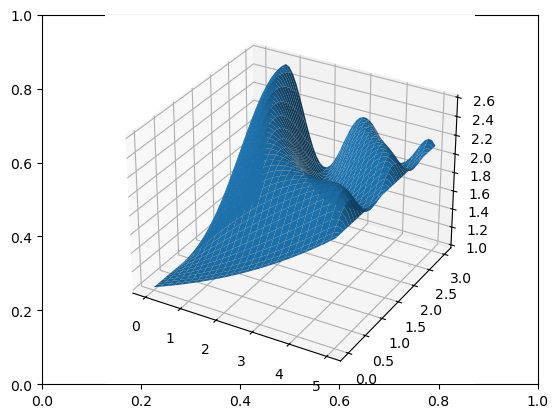

PyObject <mpl_toolkits.mplot3d.art3d.Poly3DCollection object at 0x7f73bdb56ea0>

In [3]:
using PyPlot
#using Plots
#Правая часть дифференциального уравнения.
function f(x,t)
  return sin(x*t)
end
#Начальное условие
function fi(x)
  return exp(0.15*x)
end
#Условие на левой границе
function myu(t)
  return 1
end
#Условие на правой границе
function nyu(x)
  return 2.117
end
#Решение параболического уравнения методом сеток с
#помощью явной разностной схемы. N - количество участков,
#на которые разбивается интервал по х (0,L); K - количество
#участков, на которые разбивается интервал по t (0,T); a -
#параметр дифференциального уравнения теплопроводности,
#Функция возвращает матрицу решений u и вектора x, t
#Вычисляем шаг по х
N=50
K=200
L=5
T=3
a=0.4 
#Вычисляем шаг по x
h=L/N;
#Вычисляем шаг по t
  delta=T/K;
#Формируем массив x и первый столбец матрицы решений U 
#из начального условия
x=zeros(N+1)
t=zeros(K+1)
u=zeros(N+1,K+1)
for i=1:N+1
    x[i]=(i-1)*h;
    u[i,1]=fi(x[i]);
end
#Формируем массив t, первую и последнюю строку 
#матрицы решений U из граничных условий
for j=1:K+1
    t[j]=(j-1)*delta;
    u[1,j]=myu(t[j]);
    u[N+1,j]=nyu(t[j]);
end
gam=a^2*delta/h^2;
#Формируем матрицу решений u с помощью явной разностной схемы
for j=1:K
    for i=2:N
        u[i,j+1]=gam*u[i-1,j]+(1-2*gam)*u[i,j]+gam*u[i+1,j]+delta*f(x[i],t[j]);
    end
  end
# Строим график решения
# Вывод  решения u с помощью функции surf из пакета PyPlot
PyPlot.surf(x,t,u')

**Задача 2**. Рассмотрим разностную схему для решения эллиптического уравнения

$$
\begin{array}{l}
  \displaystyle \Delta u=\frac{\partial^{2}\Psi}{\partial x^{2}} +
   \frac{\partial^{2}\Psi}{\partial y^{2}} - \frac{5}{x} \frac{\partial\Psi}{\partial x}=-2\\
\end{array}
$$

в прямоугольной области  $$\Omega (R-b\leqslant x\leqslant R+b,-a\leqslant y\leqslant a)$$
с граничными условиями Дирихле на границе $\Gamma$

$$
\Psi_{(x,y)\in \Gamma}= 0.
$$

Построим сетку  $\Omega_{hx}^{hy}$, для чего проведем в области  $\Omega$ прямые, параллельные осям $y=y_j$ и $x=x_i$, где $x_{i}=R-b+i\cdot hx$, $\displaystyle hx=\frac{2b}{Nx}$, $i=0,1,2,\ldots,Nx$, $y_{j}=-a+j\cdot hy$, $\displaystyle hy=\frac{2a}{Ny}$, $j=0,1,\ldots,Ny$. Для построения разностного уравнения заменим частные производные и граничные условия следующими соотношениями:

$$
 \begin{array}{l}
   \displaystyle
 \frac{\partial^{2}\Psi(x_{i},y_{j})}{\mathstrut\partial x^{2}} = 
  \frac{\Psi_{i-1,j}-2\Psi_{i,j}+\Psi_{i+1,j}}{hx^{2}} \\
  \displaystyle
 \frac{\partial^{2}\Psi(x_{i},y_{j})}{\partial y^{2}} =
  \frac{\Psi_{i,j-1}-2\Psi_{i,j}+\Psi_{i,j+1}}{hy^{2}}
 \end{array}
$$

$$
  \begin{array}{l}
  \Psi_{i,0} = \Psi_{i,Ny} =0,\qquad i=0,1,\ldots,Nx\\
  \Psi_{0,j} = \Psi_{Nx,j}=0,\qquad j=0,1,\ldots,Ny
  \end{array}
$$

С помощью приведённых выше соотношений преобразуем эллиптическую краевую задачу к следующей системе разностных уравнений.
$$
 \begin{array}{l}
 \displaystyle
  \Psi_{i,j} = \frac{1}{\mathstrut{}A} \left(B_{i}\Psi_{i+1,j} + C_{i}\Psi_{i-1,j} + 
   D(\Psi_{i,j-1} + \Psi_{i,j+1}) + 2\right) \\
 \displaystyle
  A = \frac{\mathstrut{}2}{hx^{2}} + \frac{2}{hy^{2}},\qquad
   B_{i} = \frac{1}{hx^{2}} + \frac{5}{2hx\,x_{i}},\qquad
   C_{i} = \frac{1}{hx^{2}} - \frac{5}{2hx\,x_{i}},\qquad
   D=\frac{1}{hy^{2}}\\
   i=1,2,\ldots,\mathstrut{}Nx-1;\qquad j=1,2,\ldots,Ny-1\\
   \Psi_{i,0}=\Psi_{i,Ny} = 0,\qquad i=0,1,\ldots,Nx\\
   \Psi_{0,j}=\Psi_{Nx,j}=0,\qquad i=0,1,\ldots ,Ny
  \end{array}
$$

Эту систему можно решать итерационными методами (например **методом Зейделя**). В случае медленной сходимости итерационных процессов при решении сеточных уравнений, получаемых при аппроксимации
гиперболических и эллиптических задач, имеет смысл попробовать заменить метод Зейделя градиентными методами (или методами релаксации). На листинге представлено решение уравнения сеточным методом, а также – график найденного решения.

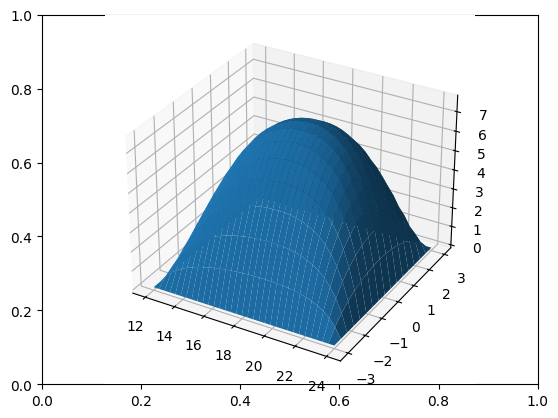

In [1]:
using PyPlot
r=18
a=3
b=6
Nx=32
Ny=16
eps=0.01    
#Входные данные:
#r, a, b - значения, определяющие область решения задачи,
#Nx - количество участков, на которые разбивается интервал по
#х(R-b,R+b);
#Ny - количество участков, на которые разбивается интервал по
#y (-a,a);
#eps - точность решения уравнения методом Зейделя.
#Выходные данные:
#psi - матрица решений в узлах сетки, массив x, массив y,
#k - количество итерация при решении разностного уравнения
# методом Зейделя.
#Вычисляем шаг по y
hy=2*a/Ny;
#Вычисляем шаг по x
hx=2*b/Nx;
x=zeros(Nx+1)
B=zeros(Nx+1)
C=zeros(Nx+1)
y=zeros(Ny+1)
psi=zeros(Nx+1,Ny+1)
R=zeros(Nx,Ny)
#Формируем массив x, первый и последний столбцы матрицы
#решений psi из граничного условия
for i=1:Nx+1
    x[i]=r-b+(i-1)*hx;
    psi[i,1]=0;
    psi[i,Ny+1]=0;
end
#Формируем массив y, первую и последнюю строки матрицы
#решений psi из граничного условия
for j=1:Ny+1
    y[j]=-a+(j-1)*hy;
    psi[1,j]=0;
    psi[Nx+1,1]=0;
end;
#Вычисляем коэффициенты разностного уравнения
A=2/hy^2+2/hx^2;
D=1/hy^2;
for i=2:Nx+1
    B[i]=1/hx^2+5/(2*hx*x[i]);
    C[i]=1/hx^2-5/(2*hx*x[i]);
end
#Решение разностного уравнения методом Зейделя с
#точностью eps
p=1;
k=0;
while p>eps
# Формируем очередное приближение - матрицу psi и матрицу ошибок R    
    for i=2:Nx
      for j=2:Ny
        V=1/A*(B[i]*psi[i-1,j]+C[i]*psi[i+1,j]+D*(psi[i,j-1]+psi[i,j+1])+2);
        R[i,j]=abs(V-psi[i,j]);
        psi[i,j]=V;
      end
    end
 # Вычисляем норму матрицы ошибок   
    p=R[2,2];
    for i=2:Nx
      for j=2:Ny
        if R[i,j]>p
          p=R[i,j];
        end
      end
    end
  k=k+1;
end
# Вывод  решения psi с помощью функции surf из пакета PyPlot
PyPlot.surf(x,y,psi');